## **Cloud Cost Intelligence System for E-commerce Using Python, Data Analytics and Streamlit**

## Project Description

Modern e-commerce platforms rely on cloud infrastructure to manage online services such as product catalogs, order processing, payment systems, and recommendation engines.

Since cloud resources scale based on user demand, managing cloud costs becomes important. This project develops a Cloud Cost Intelligence (CCI) system that simulates cloud usage data of an e-commerce platform for further cost analysis.

#### **Install Required Libraries**

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## Dataset Description

The dataset generated in this project simulates the cloud infrastructure usage of an e-commerce platform. It represents how different services of an online store consume cloud resources during daily operations.

The dataset includes multiple departments such as Product Catalog, Order Processing, Payment Service, Recommendation Engine, Customer Support, Analytics, and Inventory System.

Each record contains information about cloud resource usage including compute hours, storage usage, data transfer, API requests, active users, and CPU utilization. The dataset also includes timestamps and month information to support time-based analysis of cloud costs.

## Generate Synthetic Dataset

The dataset simulates the cloud infrastructure usage of an e-commerce platform.
It represents how different services of an online store consume cloud resources such as compute, storage, and network bandwidth.

The dataset includes multiple services including Product Catalog, Order Processing, Payment Service, Recommendation Engine, Customer Support, Analytics, and Inventory System.

Each record represents hourly cloud usage for the year 2024.

In [3]:
np.random.seed(42)

# Generate hourly timestamps for full year
timestamps = pd.date_range(
    start="2024-01-01",
    end="2024-12-31 23:00:00",
    freq="h"
)

# Departments
departments = [
    "Product Catalog",
    "Order Processing",
    "Payment Service",
    "Recommendation Engine",
    "Customer Support",
    "Analytics",
    "Inventory System"
]

# Service types
service_types = [
    "Compute",
    "Storage",
    "Database",
    "API Gateway",
    "Machine Learning"
]

# Create dataframe
df = pd.DataFrame({
    "timestamp": timestamps,
    "department": np.random.choice(departments, len(timestamps)),
    "service_type": np.random.choice(service_types, len(timestamps))
})

## Generate Cloud Usage Metrics

To represent cloud resource consumption, the following metrics are generated:

Compute Hours – processing time used by cloud servers

Storage Usage (GB) – storage consumed for product data and logs

Data Transfer (GB) – network traffic between services

API Requests – number of requests made to backend services

Active Users – number of users interacting with the platform

CPU Utilization – percentage of CPU usage

These metrics simulate the operational workload of an e-commerce system.

In [4]:
df["compute_hours"] = np.random.uniform(0.5, 12,len(timestamps))

df["storage_usage_gb"] = np.random.uniform(5, 500,len(timestamps))

df["data_transfer_gb"] = np.random.uniform(1, 200,len(timestamps))

df["api_requests"] = np.random.randint(1000, 50000,len(timestamps))

df["active_users"] = np.random.randint(50, 5000,len(timestamps))

df["cpu_utilization"] = np.random.uniform(10, 95,len(timestamps))

# Extract month for seasonal simulation
df["month"] = df["timestamp"].dt.month

#The month column is extracted from the timestamp to allow monthly cloud cost analysis.

# convert active_users to float for seasonal adjustments
df["active_users"] = df["active_users"].astype(float)

## Generate Cloud Usage Metrics

To simulate the operational workload of an e-commerce platform, the dataset includes metrics such as compute usage, storage consumption, data transfer, API requests, active users, and CPU utilization.

In [5]:
df["compute_hours"] = np.random.uniform(0.5, 12, size=len(df))

df["storage_usage_gb"] = np.random.uniform(5, 500, size=len(df))

df["data_transfer_gb"] = np.random.uniform(1, 200, size=len(df))

df["api_requests"] = np.random.randint(1000, 50000, size=len(df)).astype(float)

df["active_users"] = np.random.randint(50, 5000, size=len(df)).astype(float)

df["cpu_utilization"] = np.random.uniform(10, 95, size=len(df))


### Extract Time Features

Time-based features such as month, hour, and day of the week are extracted from the timestamp to support seasonal and behavioral analysis.

In [6]:
df["month"] = df["timestamp"].dt.month

df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = df["timestamp"].dt.dayofweek

### Simulating Night Time Traffic Reduction

E-commerce traffic is usually lower during late night hours.
To simulate this behavior, active user counts are slightly reduced during night time (12 AM to 6 AM).

In [7]:
df.loc[df["hour"] < 6, "active_users"] *= 0.6

### Simulating Weekend Traffic Increase

Online shopping activity tends to increase during weekends.
Therefore, active users are increased slightly on Saturdays and Sundays.

In [8]:
df.loc[df["day_of_week"] >= 5, "active_users"] *= 1.3

### Simulating Major E-commerce Sale Events

During large sales events such as Black Friday or festival sales, e-commerce platforms experience significant traffic spikes.
Cloud usage increases due to higher user activity and order processing.

In [9]:
# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Define ALL events (including New Year)
sale_events = {
    "New Year Sale": ["2024-01-03", "2024-01-04"],
    "Big Savings Day": ["2024-02-10", "2024-02-11"],
    "Summer Sale": ["2024-03-15", "2024-03-16"],
    "Festival Sale": ["2024-10-20", "2024-10-22"],
    "Black Friday": ["2024-11-29"],
    "Year End Sale": ["2024-12-26", "2024-12-27"]
}

# Create event column
df["event"] = "Normal"

for event, dates in sale_events.items():

    sale_period = df["timestamp"].dt.strftime("%Y-%m-%d").isin(dates)

    # Mark event
    df.loc[sale_period, "event"] = event

    # General traffic spike
    df.loc[sale_period, "active_users"] *= 2.5
    df.loc[sale_period, "api_requests"] *= 2
    df.loc[sale_period, "compute_hours"] *= 1.8
    df.loc[sale_period, "data_transfer_gb"] *= 2

    # Department-specific spike
    df.loc[sale_period & (df["department"] == "Recommendation Engine"), "compute_hours"] *= 1.5

    df.loc[sale_period & (df["department"] == "Product Catalog"), "storage_usage_gb"] *= 1.4

    df.loc[sale_period & (df["department"] == "Order Processing"), "api_requests"] *= 1.6

### Department Specific Cloud Usage Patterns

Different services of an e-commerce platform use cloud resources differently.
For example, recommendation systems require more compute power, while product catalogs require more storage.

### CPU Utilization Adjustment

CPU utilization values are limited to a maximum of 100% to maintain realistic system behavior.

In [10]:
df["cpu_utilization"] = df["cpu_utilization"].clip(upper=100)

## Cloud Cost Calculation

To simulate cloud billing, cost is calculated based on resource usage such as compute hours, storage consumption, data transfer, and API requests.

In [11]:
# Compute cost ($0.05 per compute hour)
df["compute_cost"] = df["compute_hours"] * 0.05

# Storage cost ($0.01 per GB)
df["storage_cost"] = df["storage_usage_gb"] * 0.01

# Data transfer cost ($0.02 per GB)
df["transfer_cost"] = df["data_transfer_gb"] * 0.02

# API request cost ($0.0001 per request)
df["api_cost"] = df["api_requests"] * 0.0001

##Total cost

df["total_cost"] = (
    df["compute_cost"] +
    df["storage_cost"] +
    df["transfer_cost"] +
    df["api_cost"]
)

In [12]:
df['cloud_service'] = df['service_type'].map({
    'Compute': 'EC2 / Virtual Machines',
    'Storage': 'S3 / Blob Storage',
    'Database': 'RDS / NoSQL Databases',
    'Machine Learning': 'SageMaker / AI Services'
})

## Cloud Service Mapping

Generic service types are mapped to real cloud services
Helps align dataset with actual cloud billing structure

#### Dataset Validation

The generated dataset is validated by inspecting its structure and statistical properties.

In [13]:
df.head()

,timestamp,department,service_type,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,hour,day_of_week,event,compute_cost,storage_cost,transfer_cost,api_cost,total_cost,cloud_service
0,2024-01-01 00:00:00,Inventory System,Compute,5.618294,349.161384,17.239013,26186.0,318.6,78.965316,1,0,0,Normal,0.280915,3.491614,0.344780,2.6186,6.735909,EC2 / Virtual Machines
1,2024-01-01 01:00:00,Recommendation Engine,Database,10.484158,254.783810,193.676686,9495.0,865.8,72.995172,1,1,0,Normal,0.524208,2.547838,3.873534,0.9495,7.895080,RDS / NoSQL Databases
2,2024-01-01 02:00:00,Customer Support,Machine Learning,5.972566,57.088591,145.315490,44872.0,2511.0,64.729339,1,2,0,Normal,0.298628,0.570886,2.906310,4.4872,8.263024,SageMaker / AI Services
3,2024-01-01 03:00:00,Inventory System,Compute,9.629721,462.565726,28.177948,42127.0,2092.2,64.826891,1,3,0,Normal,0.481486,4.625657,0.563559,4.2127,9.883402,EC2 / Virtual Machines
4,2024-01-01 04:00:00,Payment Service,Storage,5.042783,39.204890,110.816638,39599.0,1833.6,41.782522,1,4,0,Normal,0.252139,0.392049,2.216333,3.9599,6.820421,S3 / Blob Storage


In [14]:
df.shape

(8784, 19)

In [15]:
df.columns

Index(['timestamp', 'department', 'service_type', 'compute_hours',
       'storage_usage_gb', 'data_transfer_gb', 'api_requests', 'active_users',
       'cpu_utilization', 'month', 'hour', 'day_of_week', 'event',
       'compute_cost', 'storage_cost', 'transfer_cost', 'api_cost',
       'total_cost', 'cloud_service'],
      dtype='str')

## Dataset Columns

The generated dataset contains the following columns representing cloud resource usage of an e-commerce platform:

- **timestamp** – Time at which the cloud resource usage was recorded  
- **department** – Service or module of the e-commerce system (Product Catalog, Order Processing, etc.)  
- **service_type** – Type of cloud service used such as Compute, Storage, API Gateway, or Machine Learning  
- **compute_hours** – Amount of compute resources used in hours  
- **storage_usage_gb** – Storage consumption in gigabytes  
- **data_transfer_gb** – Network data transferred in gigabytes  
- **api_requests** – Number of API calls made to backend services  
- **active_users** – Number of users actively using the platform  
- **cpu_utilization** – CPU usage percentage of the cloud resources  
- **month** – Month extracted from the timestamp for time-based analysis  
- **compute_cost** – Cost incurred for compute resource usage  
- **storage_cost** – Cost incurred for storage consumption  
- **transfer_cost** – Cost incurred for data transfer  
- **api_cost** – Cost incurred for API requests  
- **total_cost** – Total cloud cost calculated by summing all individual costs

In [16]:
df["department"].unique()

<ArrowStringArray>
[     'Inventory System', 'Recommendation Engine',      'Customer Support',
       'Payment Service',      'Order Processing',             'Analytics',
       'Product Catalog']
Length: 7, dtype: str

In [17]:
df["service_type"].unique()

<ArrowStringArray>
['Compute', 'Database', 'Machine Learning', 'Storage', 'API Gateway']
Length: 5, dtype: str

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         8784 non-null   datetime64[us]
 1   department        8784 non-null   str           
 2   service_type      8784 non-null   str           
 3   compute_hours     8784 non-null   float64       
 4   storage_usage_gb  8784 non-null   float64       
 5   data_transfer_gb  8784 non-null   float64       
 6   api_requests      8784 non-null   float64       
 7   active_users      8784 non-null   float64       
 8   cpu_utilization   8784 non-null   float64       
 9   month             8784 non-null   int32         
 10  hour              8784 non-null   int32         
 11  day_of_week       8784 non-null   int32         
 12  event             8784 non-null   str           
 13  compute_cost      8784 non-null   float64       
 14  storage_cost      8784 non-null   f

## Statistical Summary of the Dataset

Before performing detailed analysis, it is important to understand the statistical characteristics of the dataset.

The describe() function provides summary statistics for numerical columns including:

- Count of values
- Mean (average)
- Standard deviation
- Minimum and maximum values
- Quartile ranges

This helps in understanding the distribution of cloud resource usage and cost values in the dataset.

In [19]:
df.describe()

,timestamp,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,hour,day_of_week,compute_cost,storage_cost,transfer_cost,api_cost,total_cost
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2024-07-01 23:30:00,6.462918,251.698268,103.660604,26527.107354,2581.614276,52.656015,6.513661,11.500000,2.986339,0.323146,2.516983,2.073212,2.652711,7.566051
min,2024-01-01 00:00:00,0.500547,5.072240,1.055643,1023.000000,32.400000,10.008322,1.000000,0.000000,0.000000,0.025027,0.050722,0.021113,0.102300,0.860383
25%,2024-04-01 11:45:00,3.464737,127.273063,52.287326,13594.750000,1209.975000,31.296241,4.000000,5.750000,1.000000,0.173237,1.272731,1.045747,1.359475,5.803367
50%,2024-07-01 23:30:00,6.296064,249.574668,101.558115,25967.000000,2379.650000,52.876074,7.000000,11.500000,3.000000,0.314803,2.495747,2.031162,2.596700,7.498702
75%,2024-10-01 11:15:00,9.402573,377.660773,151.604566,38212.000000,3712.005000,73.712864,10.000000,17.250000,5.000000,0.470129,3.776608,3.032091,3.821200,9.187415
max,2024-12-31 23:00:00,31.485351,693.716152,399.859393,158880.000000,15902.250000,94.980911,12.000000,23.000000,6.000000,1.574268,6.937162,7.997188,15.888000,27.348160
std,NaN,3.623179,144.329809,62.133318,16403.310889,1769.440659,24.448569,3.451430,6.922581,2.003480,0.181159,1.443298,1.242666,1.640331,2.606009


### Save Dataset

The generated dataset is saved as a CSV file for further analysis.

In [20]:

import os

# create folder if not exists
os.makedirs("../outputs/reports", exist_ok=True)

# save dataset
df.to_csv("../outputs/reports/ecommerce_cloud_cost_dataset.csv", index=False)

## Exploratory Data Analysis

#### 1. Monthly Cloud Cost Trend

This analysis shows how the total cloud cost varies across different months of the year. 
It helps identify seasonal patterns and cost spikes during major sales events.

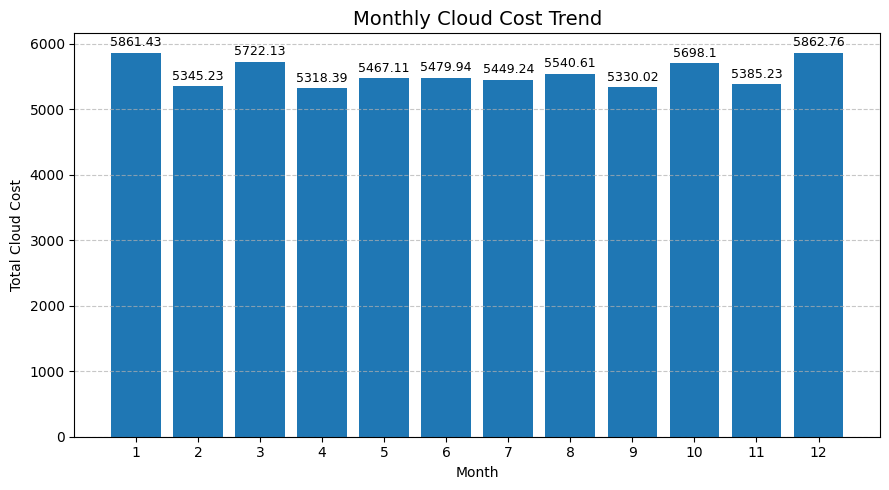

In [21]:
monthly_cost = df.groupby("month")["total_cost"].sum()

plt.figure(figsize=(9,5))

bars = plt.bar(monthly_cost.index, monthly_cost.values)

plt.title("Monthly Cloud Cost Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Cloud Cost")

plt.xticks(monthly_cost.index)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, round(yval,2),
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()


# Save figure
plt.savefig("../outputs/figures/monthly_cloud_cost.png", dpi=300, bbox_inches='tight')

plt.show()

### Observation

The monthly cloud cost remains relatively stable throughout the year, with slight increases during certain months. 
Higher costs observed in months such as October and December may be associated with seasonal sales events and increased user activity on the e-commerce platform.

#### 2. Department-wise Cloud Cost

This analysis shows how cloud costs are distributed across different services 
of the e-commerce platform.

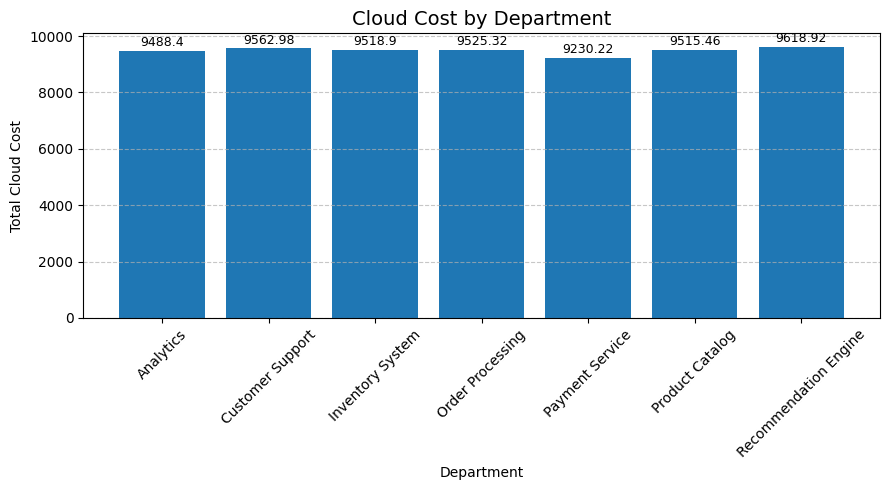

In [22]:
dept_cost = df.groupby("department")["total_cost"].sum()

plt.figure(figsize=(9,5))

bars = plt.bar(dept_cost.index, dept_cost.values)

plt.title("Cloud Cost by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Total Cloud Cost")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50,
             round(yval,2), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# Save figure
plt.savefig("../outputs/figures/department_cloud_cost.png", dpi=300, bbox_inches='tight')

plt.show()

### Observation

The visualization shows the distribution of cloud costs across different departments of the e-commerce platform. 
Order Processing and Product Catalog consume relatively higher cloud costs compared to other services. 
This is expected because these components handle core operations such as order transactions and product data management.

## 3.Service Type Usage

This visualization shows how frequently different types of cloud services 
are used in the system.

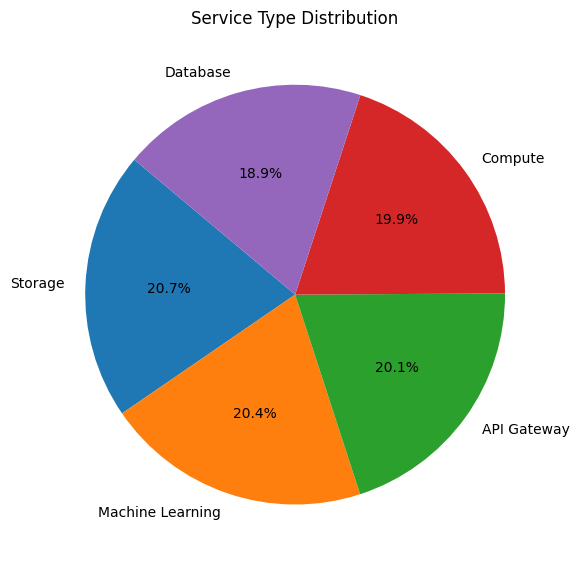

In [23]:
service_usage = df["service_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    service_usage.values,
    labels=service_usage.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Service Type Distribution")

plt.tight_layout()

plt.savefig("../outputs/figures/service_type_distribution.png", dpi=300)

plt.show()

### Observation

The pie chart illustrates the distribution of different cloud service types used in the e-commerce platform. 
Storage, Machine Learning, API Gateway, and Compute services each contribute a significant portion of the overall usage, while Database services show slightly lower usage. 
This indicates that the platform relies heavily on processing, storage, and API services to support core e-commerce operations.

## 4.CPU Utilization Distribution

This distribution shows how CPU resources are utilized across the system.

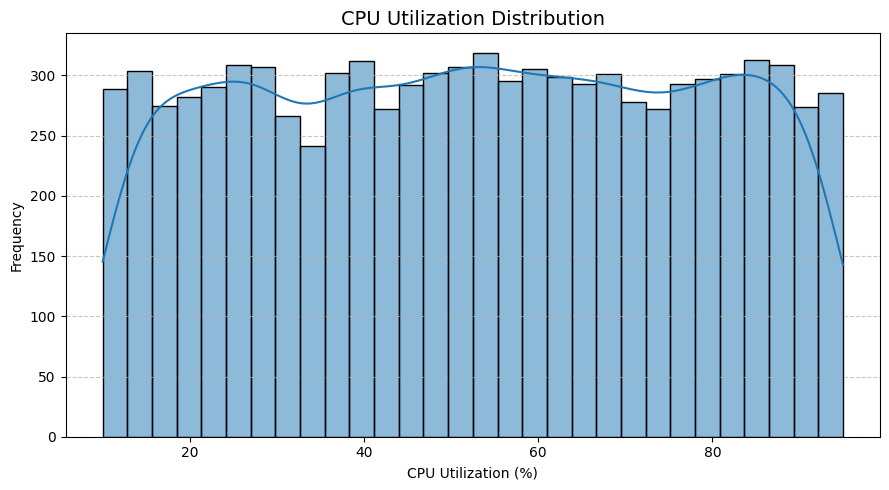

In [24]:
plt.figure(figsize=(9,5))

sns.histplot(df["cpu_utilization"], bins=30, kde=True)

plt.title("CPU Utilization Distribution", fontsize=14)
plt.xlabel("CPU Utilization (%)")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# Save figure
plt.savefig("../outputs/figures/cpu_utilization_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Observation

The distribution shows how CPU resources are utilized across the cloud infrastructure. 
Most CPU utilization values fall within the moderate range, indicating balanced resource usage across services. 
Very few instances approach higher utilization levels, suggesting that the system generally operates within safe capacity limits.

## 5.Active Users Over Time

This analysis shows how the number of active users changes over time.

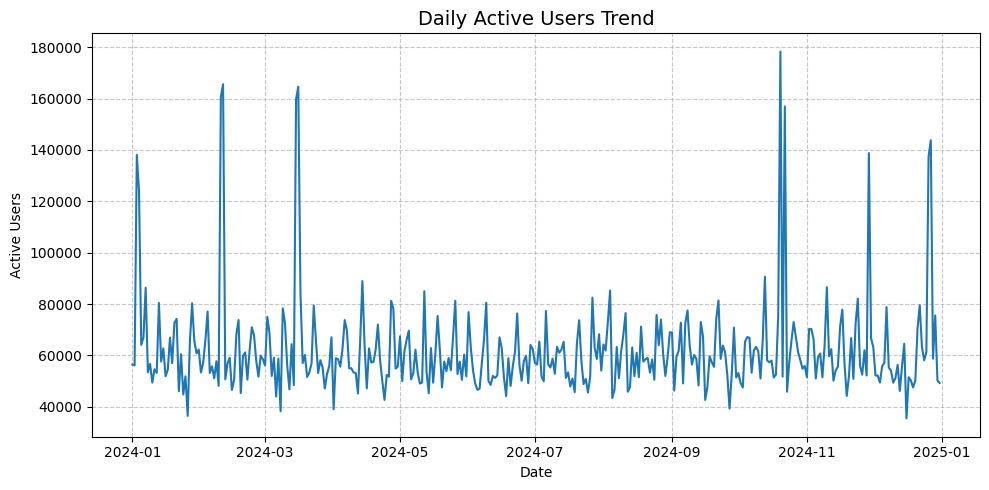

In [25]:
daily_users = df.groupby(df["timestamp"].dt.date)["active_users"].sum()

plt.figure(figsize=(10,5))

plt.plot(daily_users.index, daily_users.values, linewidth=1.5)

plt.title("Daily Active Users Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Active Users")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

# Save figure
plt.savefig("../outputs/figures/daily_active_users.png", dpi=300)

plt.show()

### Observation

The graph shows the variation in the number of active users over time. 
Most days show moderate user activity, while certain days display significant spikes in user traffic. 
These spikes likely correspond to major sale events or promotional campaigns in the e-commerce platform.

## Correlation Analysis

Correlation analysis is used to understand the relationships between different cloud usage metrics such as compute hours, storage usage, data transfer, API requests, active users, and CPU utilization.

By examining these relationships, we can identify which factors have a stronger influence on the total cloud cost and resource consumption in the e-commerce platform.

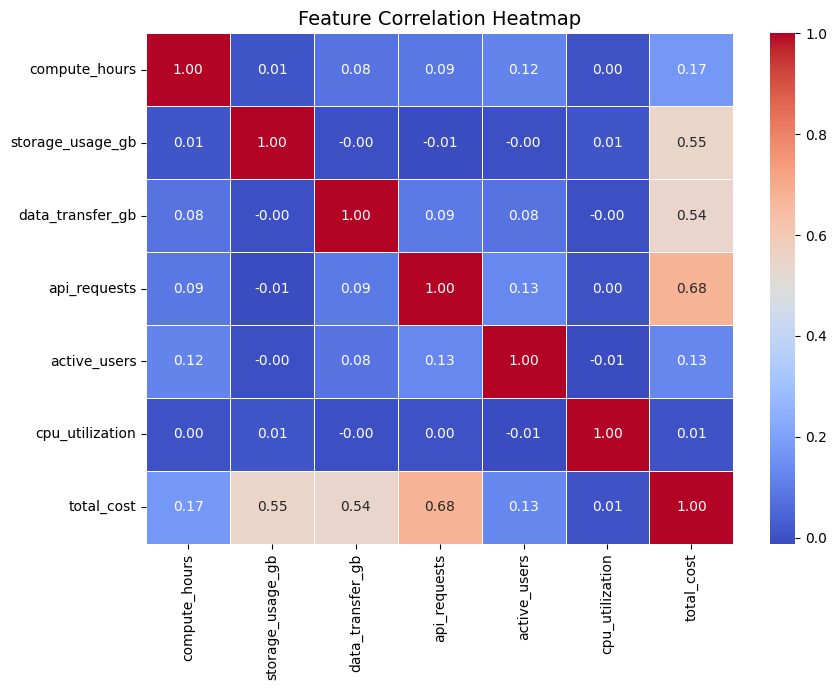

In [26]:
plt.figure(figsize=(9,7))

corr = df[[
    "compute_hours",
    "storage_usage_gb",
    "data_transfer_gb",
    "api_requests",
    "active_users",
    "cpu_utilization",
    "total_cost"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14)

plt.tight_layout()

# Save figure
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300)

plt.show()

### Observation

The correlation heatmap highlights the relationships between different cloud usage metrics and the total cloud cost. 
API requests, storage usage, and data transfer show moderate positive correlations with total cloud cost, indicating that higher activity in these resources contributes to increased expenses. 
Other features such as CPU utilization and active users exhibit relatively weaker correlations with total cost in this dataset.

## Department vs Service Cloud Cost Heatmap

This heatmap visualizes the distribution of cloud costs across different departments and cloud service types in the e-commerce platform.

By analyzing this relationship, we can identify which departments rely heavily on specific cloud services and how cloud expenses are distributed across the system.

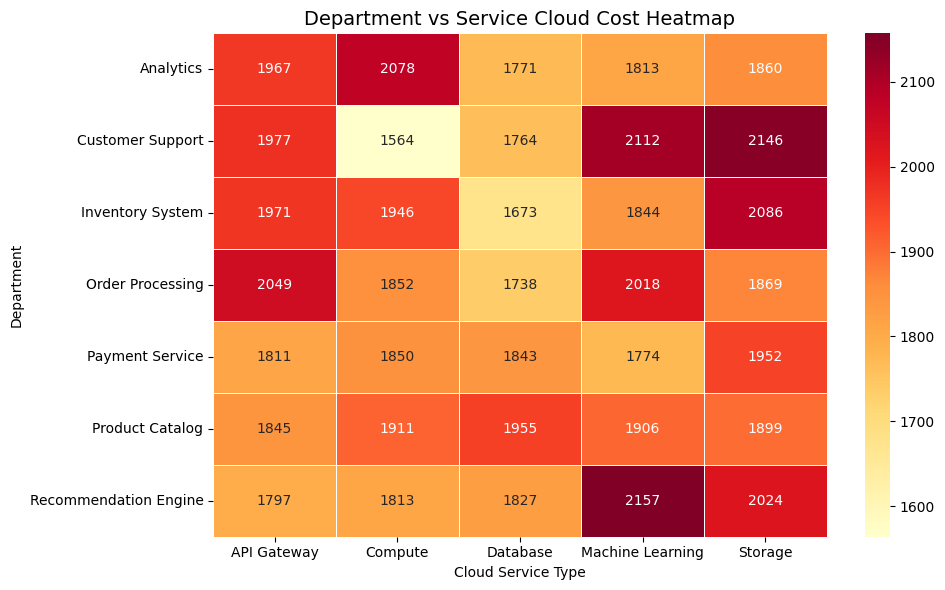

In [27]:
pivot_table = df.pivot_table(
    values="total_cost",
    index="department",
    columns="service_type",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Department vs Service Cloud Cost Heatmap", fontsize=14)
plt.xlabel("Cloud Service Type")
plt.ylabel("Department")

plt.tight_layout()

# Save figure
plt.savefig("../outputs/figures/department_service_cost_heatmap.png", dpi=300)

plt.show()

### Observation

The heatmap illustrates how cloud costs are distributed across different departments and cloud service types in the e-commerce platform. 
Order Processing and Product Catalog departments show relatively higher cloud costs across multiple services, indicating their critical role in handling core e-commerce operations. 
Machine Learning services appear to contribute significantly to the overall cost, particularly in departments such as Order Processing and Recommendation Engine.

## Cloud Cost Anomaly Detection

Anomaly detection is used to identify unusual spikes or abnormal patterns in cloud costs. 
By detecting these anomalies, organizations can investigate unexpected increases in resource usage and take corrective actions to optimize cloud spending.

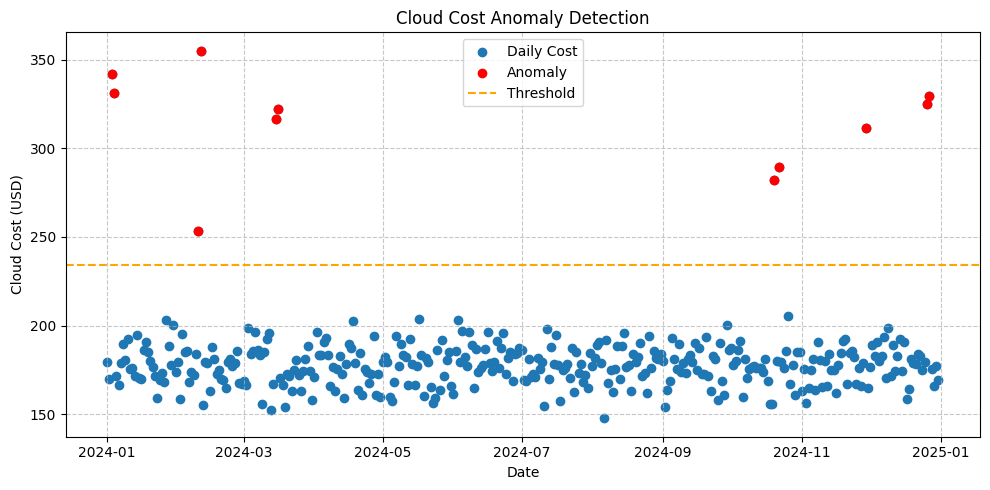

In [28]:
daily_cost = df.groupby(df["timestamp"].dt.date)["total_cost"].sum()

mean_cost = daily_cost.mean()
std_cost = daily_cost.std()

threshold = mean_cost + 2 * std_cost

anomalies = daily_cost[daily_cost > threshold]

plt.figure(figsize=(10,5))

# Normal cost points
plt.scatter(daily_cost.index, daily_cost.values, label="Daily Cost")

# Anomalies
plt.scatter(anomalies.index, anomalies.values, color="red", label="Anomaly")

plt.axhline(threshold, color="orange", linestyle="--", label="Threshold")

plt.title("Cloud Cost Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Cloud Cost (USD)")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("../outputs/figures/cloud_cost_anomaly_detection_ecommerce.png", dpi=300, bbox_inches='tight')

plt.show()

### Observation

The anomaly detection visualization highlights several days where cloud costs exceed the normal threshold level. 
These anomalies represent unusual spikes in cloud spending compared to typical daily costs. 
Such spikes may occur due to increased platform activity, promotional events, or inefficient resource utilization. 
Detecting these anomalies helps organizations investigate abnormal cloud usage and take corrective actions to control cloud expenses.

## Key Insights

From the exploratory data analysis, several important patterns in cloud resource usage were identified.

• Cloud costs vary across different departments, with services such as Order Processing and Product Catalog consuming higher cloud resources.

• Machine Learning and Compute services contribute significantly to overall cloud expenditure.

• Certain periods show spikes in user activity, which may correspond to promotional events or increased platform traffic.

• API requests and storage usage show moderate correlation with total cloud cost, indicating their influence on overall cloud expenses.

## Cost Analysis

In this section, we analyze cloud cost distribution across services, regions, and time.
This helps identify the major cost drivers in the system.

## Cost Analysis

Analyze which service types contribute most to the total cloud cost.

In [29]:
# Top services by total cost
top_services = df.groupby("service_type")["total_cost"].sum().sort_values(ascending=False)

print(top_services)

service_type
Storage             13835.464960
Machine Learning    13624.160782
API Gateway         13415.693410
Compute             13013.671740
Database            12571.204357
Name: total_cost, dtype: float64


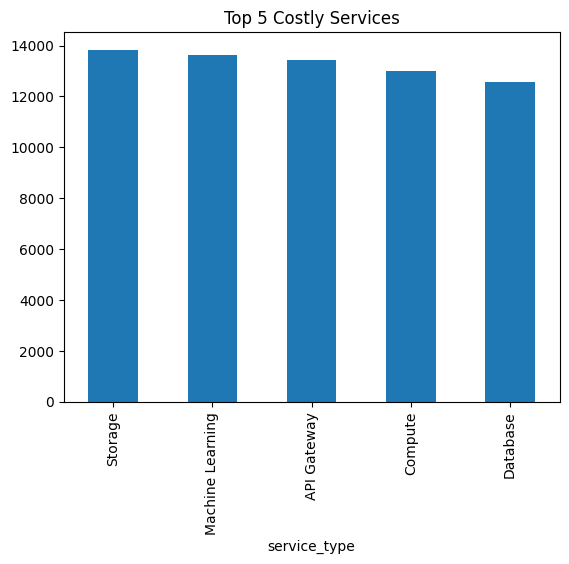

In [30]:
import matplotlib.pyplot as plt
import os

os.makedirs("../outputs/figures", exist_ok=True)

top_services.head(5).plot(kind='bar', title="Top 5 Costly Services")

plt.savefig("../outputs/figures/top_services.png")
plt.show()

## Cost Analysis Insights

- Storage is the highest cost contributor, but only slightly higher than other services.
- Machine Learning and API Gateway also contribute significantly to overall cost.
- The cost distribution is relatively balanced across services, indicating no single dominant cost driver.
- Optimization efforts should focus on multiple services rather than targeting just one.

## Time-Based Cost Trend

This analysis shows how cloud costs vary over time.
It helps identify peak usage periods and unusual spikes.

In [31]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

cost_trend = df.groupby(df["timestamp"].dt.date)["total_cost"].sum()

print(cost_trend.head())

timestamp
2024-01-01    179.243745
2024-01-02    169.748709
2024-01-03    341.702726
2024-01-04    331.235742
2024-01-05    171.292692
Name: total_cost, dtype: float64


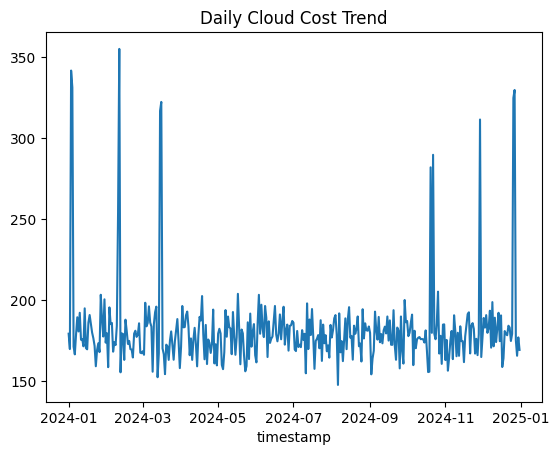

In [32]:
cost_trend.plot(title="Daily Cloud Cost Trend")

plt.savefig("../outputs/figures/cost_trend.png")
plt.show()

## Time-Based Insights

- Cloud costs show noticeable fluctuations across days.
- A significant cost spike is observed on January 3 and January 4.
- These spikes may indicate high workload, increased user activity, or inefficient resource usage in new year sale event.
- Identifying the cause of these spikes can help in optimizing cloud costs.

In [33]:
df[df["timestamp"].dt.date == pd.to_datetime("2024-01-03").date()]

,timestamp,department,service_type,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,hour,day_of_week,event,compute_cost,storage_cost,transfer_cost,api_cost,total_cost,cloud_service
48,2024-01-03 00:00:00,Product Catalog,Storage,12.220122,385.014233,43.534754,96948.0,1396.5,82.543801,1,0,2,New Year Sale,0.611006,3.850142,0.870695,9.69480,15.026644,S3 / Blob Storage
49,2024-01-03 01:00:00,Payment Service,Database,4.853302,315.085637,287.041957,3290.0,1971.0,21.152461,1,1,2,New Year Sale,0.242665,3.150856,5.740839,0.32900,9.463361,RDS / NoSQL Databases
50,2024-01-03 02:00:00,Customer Support,API Gateway,6.374452,477.915116,141.280460,36082.0,5296.5,21.385461,1,2,2,New Year Sale,0.318723,4.779151,2.825609,3.60820,11.531683,NaN
51,2024-01-03 03:00:00,Payment Service,Machine Learning,14.193100,404.266342,374.118691,77648.0,666.0,25.657863,1,3,2,New Year Sale,0.709655,4.042663,7.482374,7.76480,19.999492,SageMaker / AI Services
52,2024-01-03 04:00:00,Inventory System,API Gateway,7.495230,55.050999,54.906474,99126.0,3382.5,60.692286,1,4,2,New Year Sale,0.374762,0.550510,1.098129,9.91260,11.936001,NaN
53,2024-01-03 05:00:00,Customer Support,Storage,15.020143,258.402886,311.534296,70628.0,4942.5,27.238674,1,5,2,New Year Sale,0.751007,2.584029,6.230686,7.06280,16.628522,S3 / Blob Storage
54,2024-01-03 06:00:00,Product Catalog,Machine Learning,17.009325,307.840889,383.771728,82338.0,12092.5,62.066801,1,6,2,New Year Sale,0.850466,3.078409,7.675435,8.23380,19.838110,SageMaker / AI Services
55,2024-01-03 07:00:00,Inventory System,API Gateway,7.247126,199.754604,382.876042,67290.0,600.0,71.656111,1,7,2,New Year Sale,0.362356,1.997546,7.657521,6.72900,16.746423,NaN
56,2024-01-03 08:00:00,Order Processing,API Gateway,8.486813,74.207525,103.969013,62809.6,9692.5,82.973704,1,8,2,New Year Sale,0.424341,0.742075,2.079380,6.28096,9.526756,NaN
57,2024-01-03 09:00:00,Recommendation Engine,Machine Learning,2.904805,190.792135,119.993949,14334.0,6955.0,83.722428,1,9,2,New Year Sale,0.145240,1.907921,2.399879,1.43340,5.886441,SageMaker / AI Services


## Event-Based Cost Analysis

- During the New Year Sale, there is a significant increase in cloud usage.
- API requests, active users, and compute hours show a sharp rise.
- This leads to a noticeable increase in total cloud cost.
- API Gateway and Machine Learning services show major cost spikes.
- The system experiences higher load due to increased user activity during the sale.

### Conclusion
Sale events directly impact cloud cost due to increased traffic and system usage.

## Waste Detection

This section identifies inefficient resource usage where cost is high but utilization is low.
Such resources can be optimized to reduce cloud expenses.

In [34]:
# Define thresholds (data-driven)
low_cpu_threshold = df["cpu_utilization"].quantile(0.25)
high_cost_threshold = df["total_cost"].quantile(0.75)
low_user_threshold = df["active_users"].quantile(0.25)
high_storage_threshold = df["storage_usage_gb"].quantile(0.75)

# Waste detection logic (multi-condition)
df["is_waste"] = (
    # Idle compute resources
    ((df["cpu_utilization"] < low_cpu_threshold) & (df["compute_hours"] > 5)) |
    
    # High cost but low usage
    ((df["total_cost"] > high_cost_threshold) & (df["active_users"] < low_user_threshold)) |
    
    # Over-provisioned storage
    ((df["storage_usage_gb"] > high_storage_threshold) & (df["active_users"] < low_user_threshold))
)

# Estimate waste cost
df["waste_cost_estimate"] = df["total_cost"] * df["is_waste"] * 0.5

# Extract waste resources
waste_resources = df[df["is_waste"] == True]

# Save to CSV
waste_resources.to_csv("../outputs/reports/waste_resources.csv", index=False)

# Preview
print(waste_resources.head())

             timestamp             department      service_type  \
8  2024-01-01 08:00:00       Order Processing          Database   
17 2024-01-01 17:00:00       Customer Support           Storage   
20 2024-01-01 20:00:00              Analytics           Compute   
26 2024-01-02 02:00:00  Recommendation Engine           Storage   
34 2024-01-02 10:00:00        Payment Service  Machine Learning   

    compute_hours  storage_usage_gb  data_transfer_gb  api_requests  \
8       11.623678         32.313365        109.651890       30183.0   
17       2.661057        330.668400        196.984885       49444.0   
20      10.387936        445.875894        145.115810       47392.0   
26       9.952088        477.459098         75.770916       24100.0   
34      10.953963        283.842235        181.177830       49672.0   

    active_users  cpu_utilization  month  ...  day_of_week   event  \
8         2803.0        21.917183      1  ...            0  Normal   
17         508.0        10.261

## Waste Detection Insights
-Multiple resources exhibit low CPU utilization (<25%) combined with high operational cost, indicating idle or over-provisioned compute instances
-Storage-intensive services contribute disproportionately to total cost, suggesting potential over-allocation or unused data retention
-Low user activity with sustained infrastructure cost highlights inefficient scaling strategies
-API-related costs persist even during low utilization periods, indicating unoptimized request handling or excessive calls
## Conclusion

The analysis reveals systematic inefficiencies in resource utilization, leading to avoidable cloud expenditure.
Implementing resource optimization strategies such as rightsizing, auto-scaling, and storage cleanup can significantly reduce overall cost.

## Anomaly Detection
-Anomaly detection is used to identify unusual patterns in cloud cost
-Isolation Forest is applied as an unsupervised learning method
-Helps detect sudden spikes or abnormal resource usage

In [35]:
from sklearn.ensemble import IsolationForest

features = df[['compute_cost','storage_cost','transfer_cost','api_cost','total_cost']]

model = IsolationForest(contamination=0.05, random_state=42)

df['anomaly'] = model.fit_predict(features)

In [36]:
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

## Recommendation Engine
-A rule-based recommendation system is implemented
-Recommendations are generated using waste detection and anomaly results
-Provides actionable insights for optimizing cloud cost

In [37]:
def generate_recommendation(row):

    # 1. Highest priority: anomaly (unexpected spike)
    if row['anomaly'] == -1:
        return "Investigate abnormal cost spike"
    
    # 2. Waste detected (inefficient usage)
    elif row['is_waste']:
        return "Optimize or remove underutilized resources"
    
    # 3. Compute-heavy workload
    elif row['compute_cost'] > row['total_cost'] * 0.5:
        return "Consider reserved instances or autoscaling"
    
    # 4. Storage-heavy workload
    elif row['storage_cost'] > row['total_cost'] * 0.4:
        return "Optimize storage usage and remove unused data"
    
    # 5. API-heavy workload
    elif row['api_cost'] > row['total_cost'] * 0.3:
        return "Optimize API calls and reduce unnecessary requests"
    
    # 6. Default
    else:
        return "Monitor usage"


# Apply recommendation engine
df['recommendation'] = df.apply(generate_recommendation, axis=1)

In [38]:
df[['department','cloud_service','total_cost','is_waste','anomaly_label','recommendation']].head()

,department,cloud_service,total_cost,is_waste,anomaly_label,recommendation
0,Inventory System,EC2 / Virtual Machines,6.735909,False,Normal,Optimize storage usage and remove unused data
1,Recommendation Engine,RDS / NoSQL Databases,7.895080,False,Normal,Monitor usage
2,Customer Support,SageMaker / AI Services,8.263024,False,Normal,Optimize API calls and reduce unnecessary requ...
3,Inventory System,EC2 / Virtual Machines,9.883402,False,Normal,Optimize storage usage and remove unused data
4,Payment Service,S3 / Blob Storage,6.820421,False,Normal,Optimize API calls and reduce unnecessary requ...


In [39]:
print("Waste Distribution:\n", df['is_waste'].value_counts())

print("\nAnomaly Distribution:\n", df['anomaly_label'].value_counts())

Waste Distribution:
 is_waste
False    6763
True     2021
Name: count, dtype: int64

Anomaly Distribution:
 anomaly_label
Normal     8344
Anomaly     440
Name: count, dtype: int64


## Key Findings
-Approximately 23% of resources are identified as waste, indicating significant potential for cost optimization
-Around 5% of usage patterns are anomalous, suggesting irregular or unexpected cloud cost behavior
-Storage and API-related costs contribute notably even during lower utilization periods
-Resource allocation does not always align with actual usage, leading to inefficiencies

## Conclusion
-The Cloud Cost Intelligence system analyzes cloud expenditure across multiple services in an eCommerce environment
-Waste detection identifies underutilized resources contributing to unnecessary costs
-Anomaly detection highlights abnormal cost patterns and unexpected spikes
-A rule-based recommendation engine provides actionable insights for optimizing resource usage

Overall, the system enables data-driven cost optimization, helping improve efficiency and reduce cloud expenditure.